# Day 1: The Birth of a Neuron
## From Linear Regression to Gradient Descent
---
**Objective:** Understand how a single neuron 'learns' by adjusting its weights to minimize error.

### The Plan:
1. **Generate Synthetic Data**: Create a simple linear relationship.
2. **Manual Prediction**: See why random weights fail.
3. **The Loss Function**: Quantify 'how bad' our model is (MSE).
4. **Gradient Descent**: Use calculus to find the direction of improvement.
5. **PyTorch Implementation**: Repeat the process using `torch.autograd`.

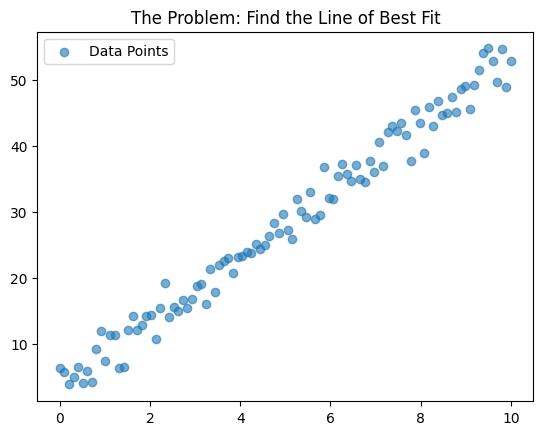

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Synthetic Data
# Formula: y = 5x + 3 (Weight=5, Bias=3)
X = torch.linspace(0, 10, 100).reshape(-1, 1)
true_w, true_b = 5.0, 3.0
noise = torch.randn(X.shape) * 2.0
y = true_w * X + true_b + noise

plt.scatter(X, y, label='Data Points', alpha=0.6)
plt.title("The Problem: Find the Line of Best Fit")
plt.legend()
plt.show()

### 1.1 The Anatomy of a Neuron
A single neuron performs a linear transformation: 
$$ 	prediction = (weight * X) + bias $$

Let's initialize a 'dumb' neuron with random weights.

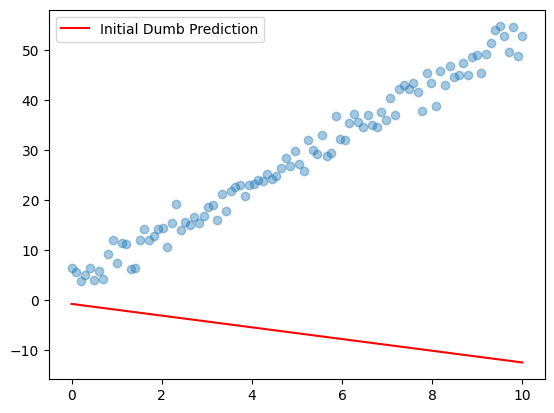

In [2]:
# Random initialization
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

def forward(x):
    return w * x + b

with torch.no_grad():
    initial_preds = forward(X)

plt.scatter(X, y, alpha=0.4)
plt.plot(X, initial_preds, color='red', label='Initial Dumb Prediction')
plt.legend()
plt.show()

### 1.2 The Loss Function (MSE)
We use **Mean Squared Error** to calculate how far off we are.
$$ MSE = \frac{1}{n} \sum (y_{pred} - y_{true})^2 $$

In [3]:
def mse_loss(y_pred, y_true):
    return ((y_pred - y_true)**2).mean()

current_loss = mse_loss(forward(X), y)
print(f"Initial Loss: {current_loss.item():.4f}")

Initial Loss: 1550.3661


### 1.3 The 'Magic' Step: Backpropagation
PyTorch's `.backward()` computes the derivative of the loss with respect to $w$ and $b$.
This tells us: **"If I increase $w$ by a tiny amount, does the loss go up or down?"**

Epoch 0: Loss 1550.3661 | w: 3.37 | b: -0.10
Epoch 10: Loss 6.5311 | w: 5.44 | b: 0.37
Epoch 20: Loss 6.3145 | w: 5.42 | b: 0.51
Epoch 30: Loss 6.1184 | w: 5.40 | b: 0.65
Epoch 40: Loss 5.9409 | w: 5.38 | b: 0.78
Epoch 50: Loss 5.7803 | w: 5.36 | b: 0.91
Epoch 60: Loss 5.6348 | w: 5.34 | b: 1.03
Epoch 70: Loss 5.5031 | w: 5.32 | b: 1.14
Epoch 80: Loss 5.3839 | w: 5.31 | b: 1.25
Epoch 90: Loss 5.2760 | w: 5.29 | b: 1.35
Epoch 100: Loss 5.1783 | w: 5.28 | b: 1.45
Epoch 110: Loss 5.0899 | w: 5.26 | b: 1.54
Epoch 120: Loss 5.0098 | w: 5.25 | b: 1.63
Epoch 130: Loss 4.9374 | w: 5.24 | b: 1.71
Epoch 140: Loss 4.8718 | w: 5.23 | b: 1.79
Epoch 150: Loss 4.8124 | w: 5.21 | b: 1.87
Epoch 160: Loss 4.7586 | w: 5.20 | b: 1.94
Epoch 170: Loss 4.7099 | w: 5.19 | b: 2.01
Epoch 180: Loss 4.6659 | w: 5.18 | b: 2.07
Epoch 190: Loss 4.6260 | w: 5.17 | b: 2.14
Epoch 200: Loss 4.5899 | w: 5.16 | b: 2.20
Epoch 210: Loss 4.5572 | w: 5.16 | b: 2.25
Epoch 220: Loss 4.5276 | w: 5.15 | b: 2.31
Epoch 230: Loss 4.

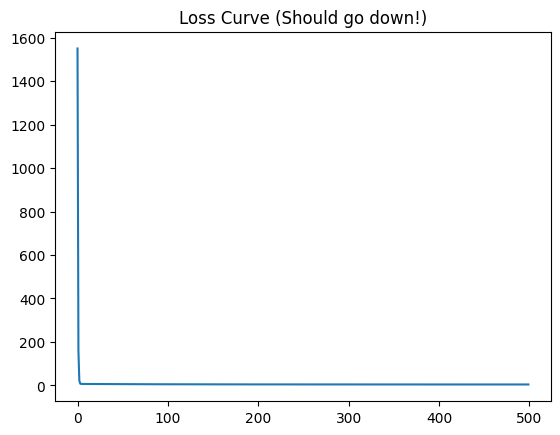

In [4]:
# Optimization Hyperparameters
lr = 0.01
epochs = 500
history = []
grad_hist = []

for i in range(epochs):
    # 1. Forward Pass
    y_pred = forward(X)
    
    # 2. Compute Loss
    loss = mse_loss(y_pred, y)
    
    # 3. Backward Pass (Calculate Gradients)
    loss.backward()
    
    # 4. Optimizer Step (Manual Update)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        grad_hist.append(w.item())
        # CRITICAL: Manually zero the gradients for the next loop
        w.grad.zero_()
        b.grad.zero_()
    
    history.append(loss.item())
    if i % 10 == 0:
        print(f"Epoch {i}: Loss {loss.item():.4f} | w: {w.item():.2f} | b: {b.item():.2f}")

plt.plot(history)
plt.title("Loss Curve (Should go down!)")
plt.show()

## Change in value of w (Should be equal or close to 5)

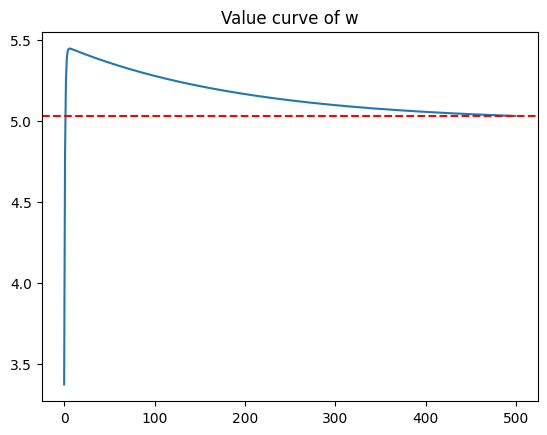

In [5]:
plt.plot(range(0,500,1),grad_hist)
plt.title("Value curve of w")
plt.axhline(y=grad_hist[-1], color='r', linestyle='--')
plt.show()

### 1.4 Result Visualization
Now let's see if the 'Trained' neuron found the line.

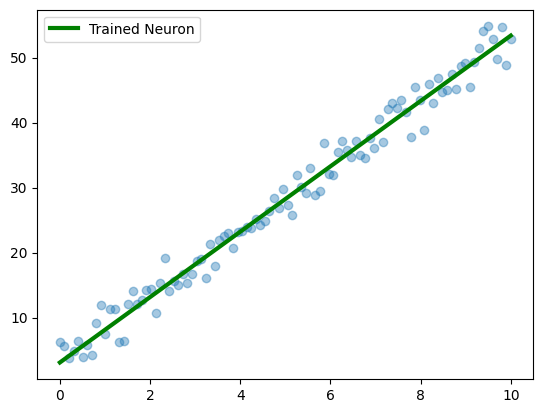

In [6]:
with torch.no_grad():
    final_preds = forward(X)

plt.scatter(X, y, alpha=0.4)
plt.plot(X, final_preds, color='green', linewidth=3, label='Trained Neuron')
plt.legend()
plt.show()

### 1.5 Professional Implementation with `nn.Linear`
Now we use the standard PyTorch way. This is how pros build networks.

In [7]:
import torch.nn as nn

class SingleNeuronModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 input feature (X), 1 output feature (y)
        self.linear = nn.Linear(1, 1)
        
    def forward(self, x):
        return self.linear(x)

model = SingleNeuronModel()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("Model Parameters:", list(model.parameters()))

Model Parameters: [Parameter containing:
tensor([[-0.4799]], requires_grad=True), Parameter containing:
tensor([-0.4950], requires_grad=True)]
